# Aprendendo a métrica induzida por uma estrutura G₂
**MM845 · relatório explicativo e laboratório de leitura**

Este notebook reúne o problema matemático, as ideias do experimento, a implementação,
os parâmetros e os resultados efetivamente medidos no projeto AI-Project.
Foi preparado para um leitor de matemática que deseja entender o papel da IA sem
precisar acompanhar cada linha dos módulos Python.

**Pode ser lido de início ao fim sem executar nenhuma célula.** Os gráficos estão
incorporados ao próprio `.ipynb`, assim como as tabelas, a configuração e as saídas dos
exemplos. Ele pode ser copiado sozinho para outra pasta. Links a artigos são referências
complementares, não dependências para entender o texto.

Se desejar reexecutar as células, use Python com NumPy, PyTorch e um kernel Jupyter.
Elas apenas fazem pequenas demonstrações e recalculam resumos de medições incorporadas;
**não treinam novamente os modelos, não baixam dados e não importam `g2metric`**.
Os exemplos didáticos são identificados como tal. As métricas publicadas vieram dos
modelos treinados na execução `full`, não dessas demonstrações.

## Percurso de leitura

1. [A pergunta e o resultado principal](#pergunta)
2. [O problema matemático](#matematica)
3. [Como são produzidos e separados os dados](#dados)
4. [Os três modelos e o treinamento](#modelos)
5. [Os parâmetros da execução](#parametros)
6. [O que significa avaliar precisão e geometria](#avaliacao)
7. [Resultados, gráficos e interpretação](#resultados)
8. [Como o código está organizado](#codigo)
9. [Conclusões, limites e continuidade](#conclusoes)
10. [Reprodutibilidade, glossário e referências](#referencias)

Primeira leitura: acompanhe os textos, tabelas e figuras. Segunda leitura: execute os
pequenos exemplos e compare as fórmulas com suas saídas. Para percorrer o repositório,
o documento `docs/roteiro-de-estudo.md` organiza sessões e exercícios complementares.

<a id="pergunta"></a>
## 1. A pergunta e o resultado principal

Uma estrutura G₂ positiva determina uma métrica por uma fórmula conhecida. Perguntamos:

> Uma rede pequena consegue aproximar essa aplicação? Treinar com mudanças de base
> por rotações ajuda a respeitar a geometria e a generalizar?

O projeto compara uma regressão linear regularizada (**ridge**), uma rede neural
totalmente conectada (**MLP**) e a mesma MLP treinada com versões rotacionadas dos dados.
A fórmula conhecida fornece respostas exatas para supervisão e verificação.

Foram gerados **30.000 pares originais**, mais **4.500 pares de extrapolação**.
Três modelos, três tamanhos de treino e três sementes produziram **27 ajustes**.

A MLP com rotações obteve os menores erros preditivos entre os três métodos e reduziu
o defeito de rotação em relação à MLP comum em todas as sementes. O ganho é modesto;
o erro permanece relevante. No maior tamanho de treino, a média das medianas entre
as sementes é aproximadamente **25% no teste usual e 43% na extrapolação**.

Isso é um resultado experimental sobre aprendizagem e generalização.
Não é uma nova fórmula de métrica, uma demonstração de equivariância ou uma
aproximação de alta precisão.

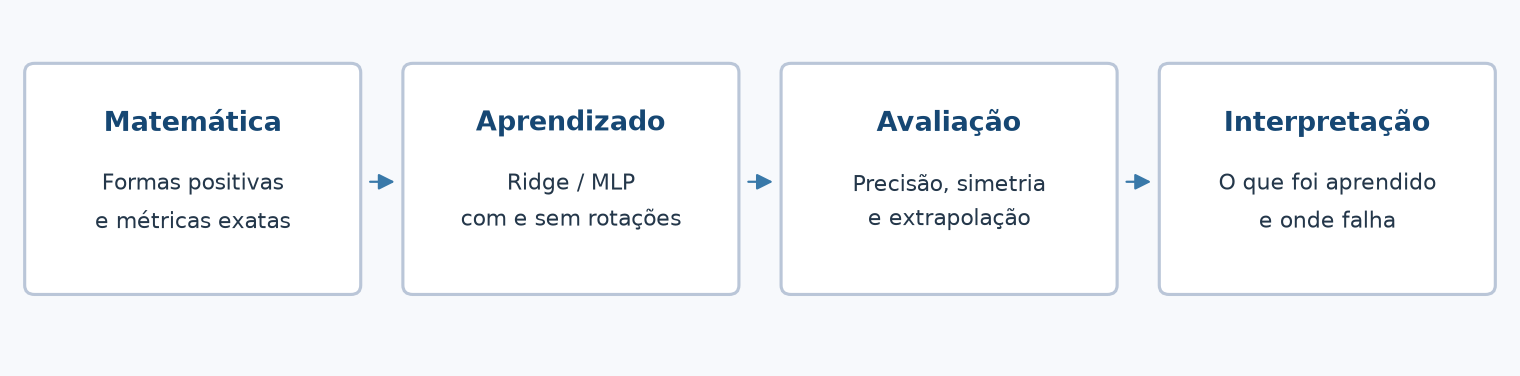

Visão geral: a matemática produz exemplos e respostas; o aprendizado aproxima a aplicação; testes independentes avaliam o resultado.

<a id="matematica"></a>
## 2. O problema matemático

Trabalhamos pontualmente em um espaço vetorial orientado $V=\mathbb{R}^7$.
Uma 3-forma é uma aplicação trilinear alternada. Na base dual fixada, escrevemos

$$\varphi=\sum_{1\leq i<j<k\leq7}\varphi_{ijk}\,e^i\wedge e^j\wedge e^k.$$

Há $\binom{7}{3}=35$ coeficientes independentes. Uma métrica é representada por uma
matriz simétrica positiva definida de dimensão 7; portanto tem $7\cdot8/2=28$
entradas independentes. A tarefa de regressão é

$$F:\mathcal P\subset\mathbb R^{35}\longrightarrow\mathrm{Sym}^+(7),
\qquad\varphi\longmapsto g_\varphi.$$

**Não é qualquer vetor de 35 números que pertence ao domínio positivo.** Fixamos

$$\varphi_0=e^{123}+e^{145}+e^{167}+e^{246}-e^{257}-e^{347}-e^{356},$$

e geramos formas na órbita $\mathcal P=\{A^*\varphi_0:A\in GL^+(7,\mathbb R)\}$.
Aqui $GL^+(7)$ denota as matrizes invertíveis de determinante positivo.
O pullback é definido por $(A^*\varphi)(u,v,w)=\varphi(Au,Av,Aw)$.
Em particular, $g_{\varphi_0}=I$ e $g_{A^*\varphi_0}=A^TA$.

O estabilizador de $\varphi_0$ é o grupo G₂. A construção é algébrica e pontual:
não resolvemos equações diferenciais nem impomos condições de torção nula.

### Duas maneiras de obter a resposta

**Para gerar rótulos**, conhecemos A e calculamos $g=A^TA$.
**Para validar**, usamos apenas a forma $\varphi$ e a álgebra exterior:

$$(B_\varphi)_{ij}\,\mathrm{vol}_0=
  \frac16(\iota_{e_i}\varphi)\wedge(\iota_{e_j}\varphi)\wedge\varphi,
  \qquad g_\varphi=(\det B_\varphi)^{-1/9}B_\varphi.$$

A contração $\iota_{e_i}$ insere o vetor $e_i$ no primeiro argumento da forma.
O produto exterior produz uma 7-forma, cujo coeficiente relativo ao volume
padrão define a entrada de B. O fator determinante ajusta o volume.

Esses caminhos são diferentes: conferir novamente `A.T @ A` não validaria a fórmula
a partir de $\varphi$. O módulo `geometry.py` implementa a segunda rota e os testes
verificam também identidade, transformações diagonais, composição e escala.

### Exemplo executável: dimensões e uma transformação diagonal

O exemplo abaixo usa um A diagonal para tornar a conta transparente: o coeficiente
de `e^i ∧ e^j ∧ e^k` é multiplicado por `a_i a_j a_k`. É um caso didático;
o gerador do experimento inclui rotações independentes e formas muito mais gerais.

In [1]:
import itertools
import math
import numpy as np

triplas = list(itertools.combinations(range(7), 3))
sinais = {(0,1,2): 1, (0,3,4): 1, (0,5,6): 1, (1,3,5): 1,
          (1,4,6): -1, (2,3,6): -1, (2,4,5): -1}
phi0 = np.array([sinais.get(t, 0) for t in triplas], dtype=float)
a = np.exp(np.linspace(-0.35, 0.35, 7))
phi_diagonal = phi0 * np.array([a[i]*a[j]*a[k] for i,j,k in triplas])
g_diagonal = np.diag(a**2)
print(f"Entrada: {math.comb(7,3)} coeficientes; saída: {7*8//2} entradas independentes.")
print("Coeficientes não nulos de phi0:", np.count_nonzero(phi0))
print("Autovalores da métrica diagonal:", np.round(np.linalg.eigvalsh(g_diagonal), 4))
print("Todos positivos:", bool(np.all(np.linalg.eigvalsh(g_diagonal) > 0)))

Entrada: 35 coeficientes; saída: 28 entradas independentes.
Coeficientes não nulos de phi0: 7
Autovalores da métrica diagonal: [0.4966 0.6271 0.7919 1.     1.2628 1.5947 2.0138]
Todos positivos: True


### As identidades geométricas que desejamos testar

A naturalidade da aplicação exata diz que

$$F(C^*\varphi)=C^TF(\varphi)C \quad (C\in GL^+(7)).$$

A forma de entrada e a matriz de saída **mudam juntas**. Isso é equivariância,
diferente de invariância, em que a saída permaneceria igual. Para uma rotação,
$C^TC=I$ e $\det C=1$; o conjunto dessas matrizes é $SO(7)$.

Tomando $C=t^{1/3}I$, obtemos a lei de escala

$$F(t\varphi)=t^{2/3}F(\varphi)\quad(t>0).$$

Por exemplo, multiplicar a forma por 8 deve multiplicar sua métrica por 4.
Estas identidades são propriedades da fórmula exata. Uma MLP genérica não as
satisfaz automaticamente, mesmo que sua saída seja simétrica e positiva definida.

<a id="dados"></a>
## 3. De onde vêm os dados?

Para cada exemplo, sorteamos

$$A=Q_1\operatorname{diag}(e^{s_1},\ldots,e^{s_7})Q_2,
  \quad Q_1,Q_2\sim\mathrm{Haar}(SO(7)),\quad s_i\sim U[-0{,}35,0{,}35].$$

Haar significa uma distribuição uniforme no grupo, sem privilegiar uma orientação.
A implementação usa matrizes gaussianas e fatoração QR, corrigindo sinais e determinante.
As matrizes Q são independentes. Os valores singulares de A são $e^{s_i}$;
variar os s permite escalas e anisotropias. Usar apenas A ortogonal daria sempre
$A^TA=I$, um problema trivial de rótulo constante.

Cada par é $(\varphi,g)=(A^*\varphi_0,A^TA)$, calculado em `float64`.
A rede recebe **somente os 35 coeficientes de $\varphi$**, nunca A ou seus valores singulares.
O treino usa tensores `float32`; as referências e diagnósticos NumPy usam `float64`.

O experimento possui três partições de fontes independentes:

| Partição | Quantidade | Função |
| --- | ---: | --- |
| Treino | 21.000 | Ajustar pesos e estatísticas da padronização |
| Validação | 4.500 | Escolher alpha do ridge e a época da MLP |
| Teste ID | 4.500 | Medir desempenho final na distribuição de treino |
| Teste OOD, adicional | 4.500 | Medir extrapolação fora da faixa de geração |

ID significa *in distribution*; OOD, *out of distribution*. O teste OOD usa
$s_i\in[-0{,}7,0{,}7]$ condicionado a $\max_i|s_i|>0{,}35$.
Assim, pelo menos um valor singular fica fora do intervalo do treino. Não basta
sortear na faixa maior e chamar todos os exemplos de extrapolação.

### Como evitamos vazamento de informação

A divisão 70%/15%/15% acontece **antes** de criar versões transformadas.
Um exemplo rotacionado herda a partição de sua fonte. Nenhum rótulo do teste
participa do ajuste, da padronização ou da escolha de hiperparâmetros.

Para cada tamanho de treino, usamos subconjuntos aninhados de 2.100, 7.000 e
21.000 fontes. Os três métodos recebem as mesmas fontes em cada comparação.
As estatísticas de padronização são calculadas só nesse subconjunto e compartilhadas:

$$x_j=(\varphi_j-\mu_j)/\sigma_j.$$

Isso é uma transformação afim dos atributos e conserva a informação de escala.
Dividir **cada forma** por sua norma seria outra operação e poderia apagar a
informação necessária para a lei $F(t\varphi)=t^{2/3}F(\varphi)$.

Todas as formas positivas pertencem à mesma órbita GL⁺(7). Portanto, aqui não faz
sentido separar treino e teste por órbitas GL⁺ inteiras: a unidade de separação é a fonte.

<a id="modelos"></a>
## 4. Três modelos para a mesma tarefa

| Modelo | O que ajusta | O que garante | Papel |
| --- | --- | --- | --- |
| Ridge | Mapa afim de 35 para 28 entradas, com penalidade nos coeficientes | Simetria ao reconstruir a matriz | Comparador linear simples |
| MLP | Duas camadas ocultas de 128 unidades e saída de 28 parâmetros | Simetria e positividade via fator triangular | Aproximação não linear |
| MLP com rotações | Mesma arquitetura, com versões rotacionadas durante o treino | Mesmas garantias da MLP | Investigar o efeito da augmentação |

**Ridge.** Ajusta $XW+b$ com penalidade $\alpha\|W\|^2$; o intercepto não é penalizado.
O problema é resolvido por mínimos quadrados aumentados, sem inverter explicitamente
$X^TX$. Alpha é escolhido pela perda relativa na validação. A predição simétrica
pode ser indefinida; não fazemos uma correção que esconda essa falha.

**MLP.** A arquitetura é `35 → 128 → 128 → 28`, com ReLU após cada camada oculta.
Os 28 números preenchem um fator triangular inferior L. Sua diagonal passa por
`softplus(z) + 10⁻⁵`, tornando-se estritamente positiva, e a resposta é $\hat g=LL^T$.
Para L invertível, $v^TLL^Tv=\|L^Tv\|^2>0$ quando $v\ne0$.

São 24.732 parâmetros treináveis. A garantia de positividade é em aritmética exata;
as avaliações também contam eventuais falhas numéricas. Essa parametrização **não**
garante equivariância.

### Exemplo executável: por que a saída é positiva?

Esta miniatura reproduz a arquitetura e a transformação da saída, mas usa **pesos
aleatórios, sem treinamento**. Sua finalidade é mostrar shapes, número de parâmetros
e positividade. Sua predição não deve ser comparada aos resultados científicos.

In [2]:
import torch
from torch import nn
from torch.nn import functional as F

torch.manual_seed(7)
rede_demonstracao = nn.Sequential(
    nn.Linear(35, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 28)
)
with torch.no_grad():
    z = rede_demonstracao(torch.tensor(phi0, dtype=torch.float32))
    linhas, colunas = torch.tril_indices(7, 7)
    z = torch.where(linhas == colunas, F.softplus(z) + 1e-5, z)
    L = torch.zeros(7, 7)
    L[linhas, colunas] = z
    g_demo = L @ L.T
print("Parâmetros:", sum(p.numel() for p in rede_demonstracao.parameters()))
print("Shape da predição:", tuple(g_demo.shape))
print("Menor autovalor:", round(torch.linalg.eigvalsh(g_demo).min().item(), 6))
print("Exemplo sem treinamento; não é uma métrica predita pelos checkpoints reais.")

Parâmetros: 24732
Shape da predição: (7, 7)
Menor autovalor: 0.338095
Exemplo sem treinamento; não é uma métrica predita pelos checkpoints reais.


### Perda, otimização e parada antecipada

O treinamento minimiza a média do erro relativo de Frobenius **ao quadrado**:

$$\mathcal L=\frac1N\sum_{n=1}^N
  \frac{\|\hat g_n-g_n\|_F^2}{\|g_n\|_F^2}.$$

A norma de Frobenius soma quadrados das 49 entradas; os termos fora da diagonal
aparecem duas vezes, como deve ocorrer para a matriz completa. Normalizar por
$\|g_n\|_F^2$ torna cada comparação relativa à escala da métrica correspondente.

Adam atualiza os pesos em minibatches. Ao fim de cada época, medimos a perda na
validação, sem atualizar os pesos com esses dados. A parada antecipada encerra a
execução após 15 épocas sem melhora suficiente; o checkpoint restaurado é sempre
aquele com a **menor perda de validação**, mesmo que uma melhora seja menor que o
limiar usado para a paciência. Não se escolhe o modelo pelo teste.

### O que muda com augmentação?

Durante o treinamento, uma nova rotação $C\in SO(7)$ transforma cada exemplo:

$$(\varphi,g)\longmapsto(C^*\varphi,\ C^TgC).$$

A transformação é aplicada aos dados **crus, antes da padronização**. Alterar a
forma e manter g fixo seria ensinar uma resposta incorreta, pois a métrica é uma
saída tensorial. As rotações preservam a faixa dos valores singulares; os dados
OOD continuam fora do suporte treinado.

Os dois braços MLP compartilham arquitetura, fontes, pesos iniciais, ordem dos
minibatches e orçamento máximo. Um gerador aleatório separado sorteia as rotações.
A parada antecipada pode produzir números efetivos diferentes de épocas.

**Sutileza:** Q₂ já é Haar. Multiplicar Q₂ por uma rotação mantém sua distribuição.
A população geradora já é rotacionalmente invariante; a augmentação fornece novas
versões de uma amostra finita, e não um suporte populacional maior. Uma melhora
precisa ser medida, não pressuposta.

In [3]:
# Exemplo geométrico pequeno: a mudança de base deve transformar o rótulo.
angulo = 0.7
C = np.eye(7)
C[:2, :2] = [[np.cos(angulo), -np.sin(angulo)],
            [np.sin(angulo),  np.cos(angulo)]]
g_rotacionada = C.T @ g_diagonal @ C
print("A matriz mudou:", not np.allclose(g_diagonal, g_rotacionada))
print("Os autovalores foram preservados:",
      np.allclose(np.linalg.eigvalsh(g_diagonal), np.linalg.eigvalsh(g_rotacionada)))
print("É uma rotação própria:", np.allclose(C.T @ C, np.eye(7)) and np.isclose(np.linalg.det(C), 1))

A matriz mudou: True
Os autovalores foram preservados: True
É uma rotação própria: True


<a id="parametros"></a>
## 5. Parâmetros e decisões da execução

O planejamento prescreve a tarefa, o gerador, a comparação, o split, a arquitetura
inicial e os diagnósticos. Valores operacionais que ele deixa em aberto foram
fixados na configuração antes de executar o experimento.

| Componente | Valor | Finalidade |
| --- | --- | --- |
| Dados ID / OOD | 30.000 / 4.500 | Distribuição de referência e extrapolação |
| Faixa de log valores singulares | ±0,35 / ±0,7 | Controlar escala e anisotropia |
| Split ID | 70% / 15% / 15% | Treino / validação / teste |
| Tamanhos de treino | 2.100, 7.000, 21.000 | Curvas de aprendizagem |
| Seeds de treino | 11, 22, 33 | Variabilidade entre ajustes |
| Seed de dados / avaliação | 2026 / 8405 | Geração e diagnósticos reproduzíveis |
| Arquitetura | 35–128–128–28 | Duas camadas ocultas com ReLU |
| Saída | Softplus na diagonal + 10⁻⁵, L Lᵀ | Positividade |
| Adam | learning rate 0,001; batch 256 | Atualização por minibatches |
| Máximo de épocas | 100 | Mesmo teto para ambas as MLPs |
| Paciência / melhora mínima | 15 / 10⁻⁵ | Parada por validação |
| Alpha do ridge | 10⁻⁴, 10⁻², 1, 100, 10.000 | Seleção na validação; soma de quadrados |
| Precisão preditiva | Todos os 4.500 exemplos por teste | Mediana, p95 e média |
| Diagnóstico geométrico | 512 exemplos por domínio | Rotações, GL⁺ e escala |
| Mudança de base GL⁺ | log valores singulares em ±0,2 | Teste não ortogonal separado |
| Fatores t da escala | 0,25; 0,5; 2; 4 | Testar homogeneidade |
| Verificação exterior inicial | 64 amostras ID e 64 OOD, mais identidade | Conferir rótulos por outra rota |
| Execução | CPU, 2 threads | Ambiente registrado |

Para tornar “sem perda material de precisão” mensurável, foi declarada tolerância
de **5% de aumento relativo na mediana do erro**, em ID e OOD, em cada semente,
no maior conjunto de treino. Além disso, a mediana do defeito SO(7) deve diminuir
em todas as sementes nos dois domínios. Essa tolerância é uma escolha operacional,
não um valor imposto pelo PDF nem um teste de significância estatística.

A célula seguinte guarda a configuração integral dentro deste notebook. A
execução `smoke`, com poucos dados e quatro épocas, verificou o software;
seus números não entram nas conclusões científicas abaixo.

In [4]:
import json

CONFIG = json.loads(r'''{
  "name": "full",
  "data": {
    "n_samples": 30000,
    "n_ood": 4500,
    "seed": 2026,
    "log_bound": 0.35,
    "ood_log_bound": 0.7,
    "validation_samples": 64
  },
  "seeds": [
    11,
    22,
    33
  ],
  "train_sizes": [
    2100,
    7000,
    21000
  ],
  "hidden_dim": 128,
  "diagonal_eps": 1e-05,
  "batch_size": 256,
  "max_epochs": 100,
  "patience": 15,
  "min_delta": 1e-05,
  "learning_rate": 0.001,
  "ridge_alphas": [
    0.0001,
    0.01,
    1.0,
    100.0,
    10000.0
  ],
  "evaluation_samples": 512,
  "evaluation_seed": 8405,
  "gl_log_bound": 0.2,
  "scale_factors": [
    0.25,
    0.5,
    2.0,
    4.0
  ],
  "accuracy_tolerance_relative": 0.05,
  "threads": 2,
  "device": "cpu"
}''')
print('Configuração incorporada:', CONFIG['name'])
print('Ajustes:', 3 * len(CONFIG['seeds']) * len(CONFIG['train_sizes']))

Configuração incorporada: full
Ajustes: 27


<a id="avaliacao"></a>
## 6. Avaliar a resposta e avaliar a geometria

**Precisão:** $E=\|\hat g-g\|_F/\|g\|_F$. Diferentemente da loss, aqui não elevamos
o erro ao quadrado. Mediana significa o valor central dos erros; p95 é o limiar
abaixo do qual estão aproximadamente 95% dos erros.

**Equivariância:**

$$E_{eq}(\varphi,C)=
\frac{\|\hat g(C^*\varphi)-C^T\hat g(\varphi)C\|_F}
     {\|C^Tg_\varphi C\|_F}.$$

O denominador usa a **métrica verdadeira**, não a predita. Testamos rotações novas
e matrizes GL⁺ limitadas separadamente, com as mesmas transformações para todos os
modelos. Transformações não ortogonais podem levar formas para fora do suporte ID.

**Escala:** comparamos $\hat g(t\varphi)$ tanto a $t^{2/3}\hat g(\varphi)$
(defeito da identidade) quanto a $t^{2/3}g_\varphi$ (erro contra a verdade).
Também contamos predições com menor autovalor não positivo.

**Por que separar tudo isso?** A aplicação incorreta $2F$ é perfeitamente
equivariante e homogênea, mas tem erro relativo 1. Uma predição constante $cI$
respeita todas as rotações, mas pode ignorar a forma. A identidade geométrica
e a precisão medem coisas diferentes.

In [5]:
# Um erro de 10% em toda a matriz gera loss quadrática de 1%.
g_verdadeira = g_diagonal
g_predita = 1.10 * g_verdadeira
erro = np.linalg.norm(g_predita - g_verdadeira, "fro") / np.linalg.norm(g_verdadeira, "fro")
print(f"Erro relativo: {erro:.1%}; contribuição para a loss: {erro**2:.4f}")

# Contraexemplo: a predição constante c I é equivariante por rotações.
constante = 1.08 * np.eye(7)
defeito = np.linalg.norm(constante - C.T @ constante @ C, "fro")
erro_constante = np.linalg.norm(constante - g_verdadeira, "fro") / np.linalg.norm(g_verdadeira, "fro")
print(f"Numerador do defeito de rotação de cI: {defeito:.2e}")
print(f"Erro preditivo de cI neste exemplo: {erro_constante:.1%}")

Erro relativo: 10.0%; contribuição para a loss: 0.0100
Numerador do defeito de rotação de cI: 9.98e-17
Erro preditivo de cI neste exemplo: 41.5%


<a id="resultados"></a>
## 7. Resultados medidos

As tabelas abaixo usam o maior subconjunto de treino: **21.000 fontes**.
Primeiro calculamos mediana e p95 para cada semente. Depois mostramos a
**média ± desvio padrão amostral dessas estatísticas entre as três sementes**.
Isso não é a mediana de um conjunto formado juntando todas as previsões;
o desvio padrão também não é um intervalo de confiança.

### 7.1 Precisão preditiva

| Modelo | ID: mediana | ID: p95 | OOD: mediana | OOD: p95 |
| --- | ---: | ---: | ---: | ---: |
| Ridge | 36,58 ± 0,00% | 48,29 ± 0,00% | 62,29 ± 0,00% | 72,86 ± 0,00% |
| MLP | 25,81 ± 0,09% | 33,92 ± 0,21% | 43,57 ± 0,08% | 64,60 ± 0,46% |
| MLP com rotações | 24,99 ± 0,07% | 33,25 ± 0,19% | 42,79 ± 0,01% | 62,87 ± 0,43% |

A não linearidade ajuda: as MLPs superam o ridge em precisão. A augmentação
melhora modestamente o resultado no maior treino e mais claramente nos treinos
menores. O erro continua alto, e piora na extrapolação. “Melhor que o baseline”
não significa “preciso o bastante para uma aplicação científica”.

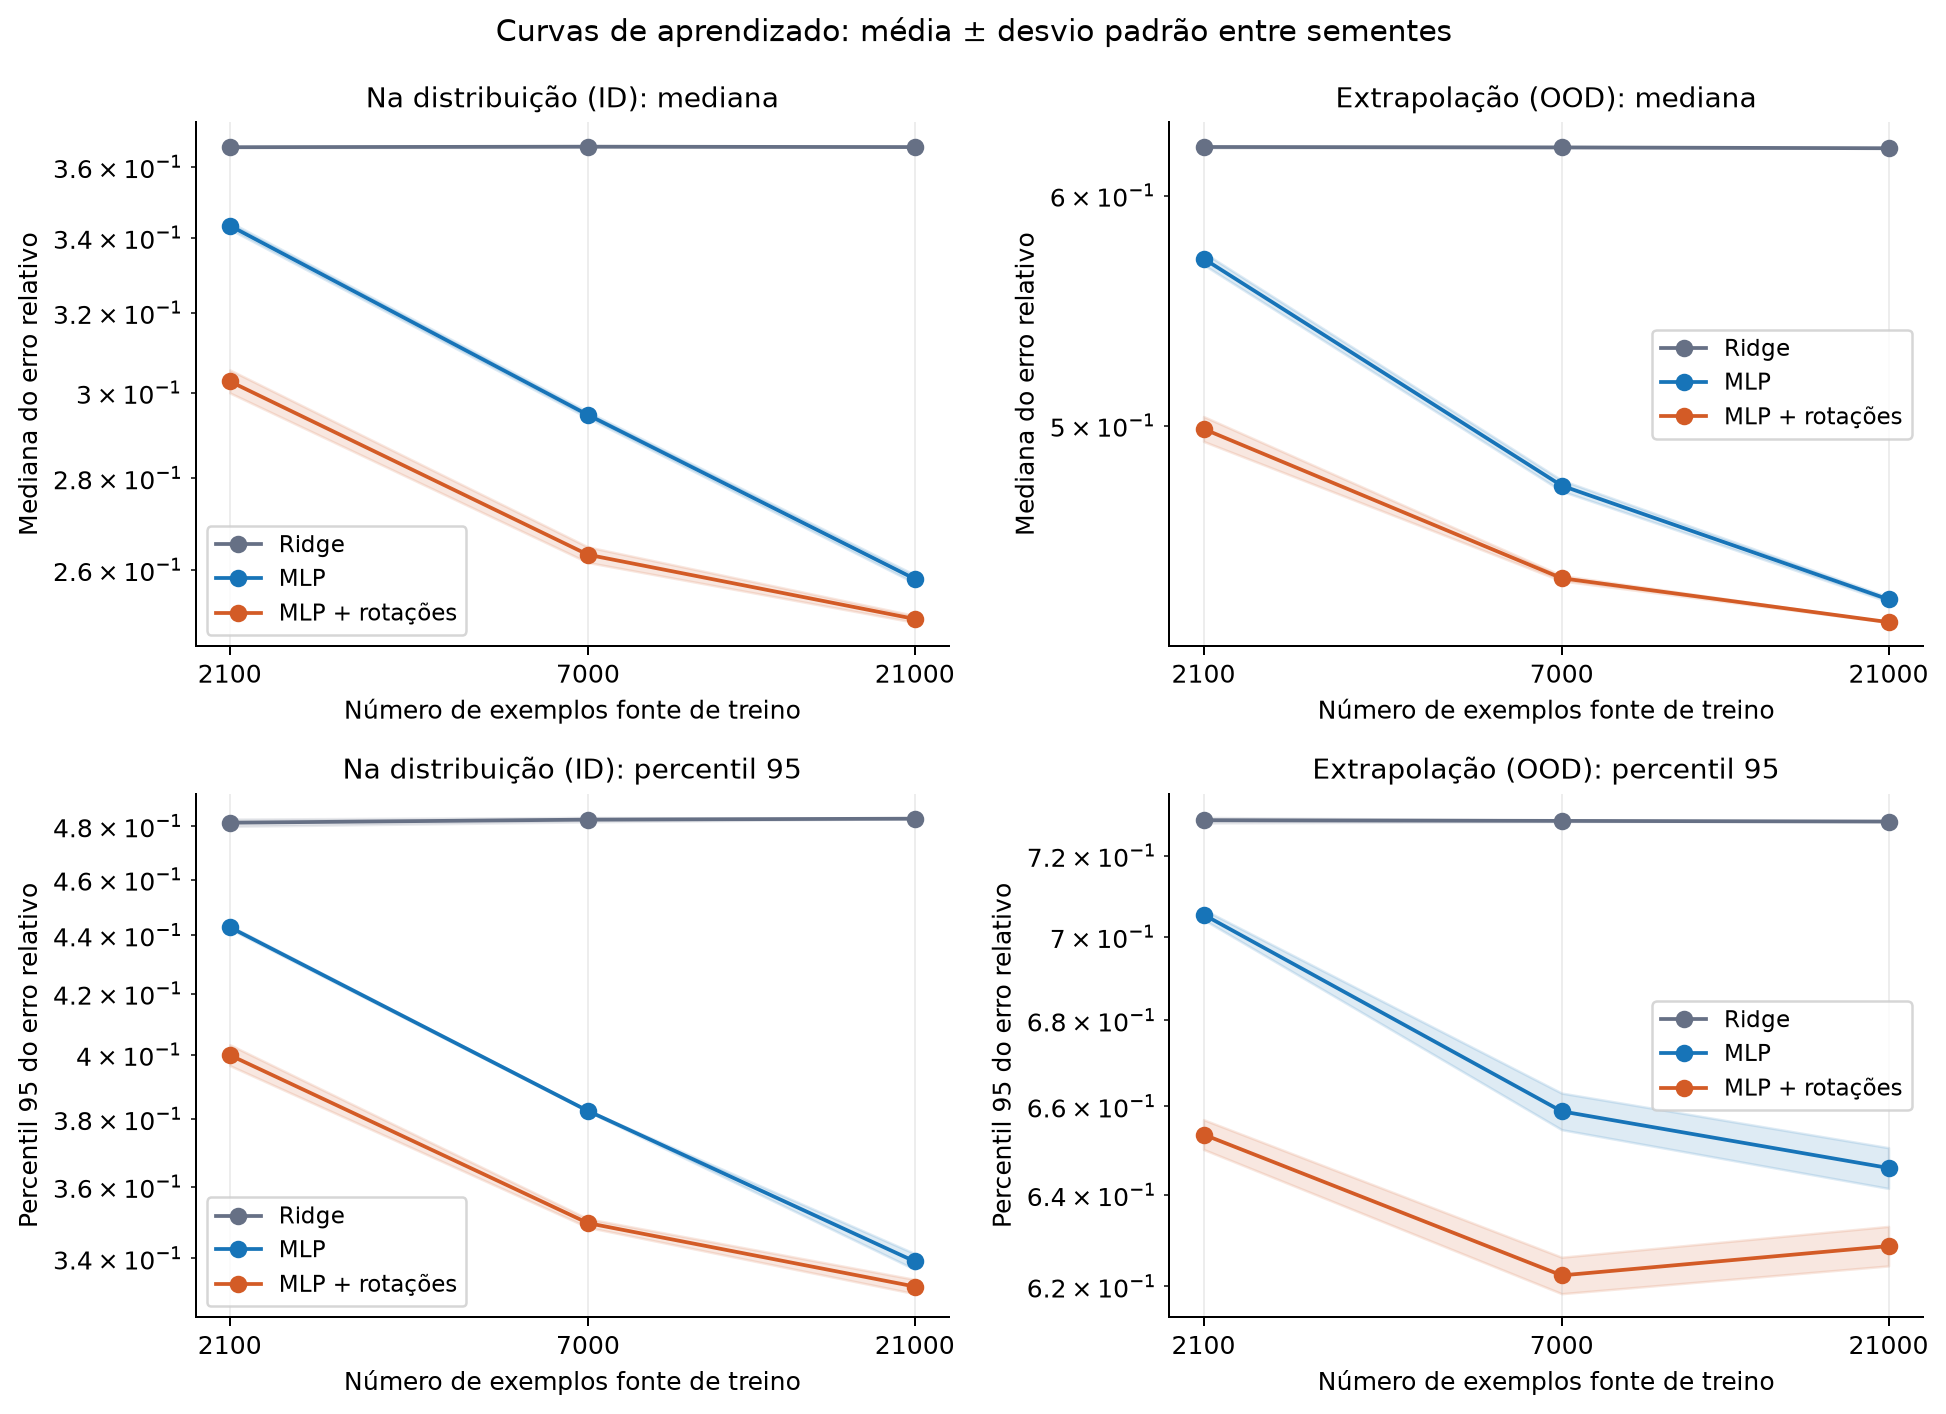

Figura 1 — Erro mediano e p95 em função do número de fontes de treino. Linhas: médias entre sementes; faixas: ± um desvio padrão. Os eixos usam escala logarítmica.

**Como ler:** compare as curvas de mesma cor à medida que cresce o treino;
depois compare laranja (augmentação) com azul (MLP comum). Olhe também o p95:
a mediana pode melhorar enquanto uma cauda de casos difíceis permanece.
O ridge pouco se beneficia do aumento de dados nessa representação linear.

### 7.2 O que ocorreu durante a otimização?

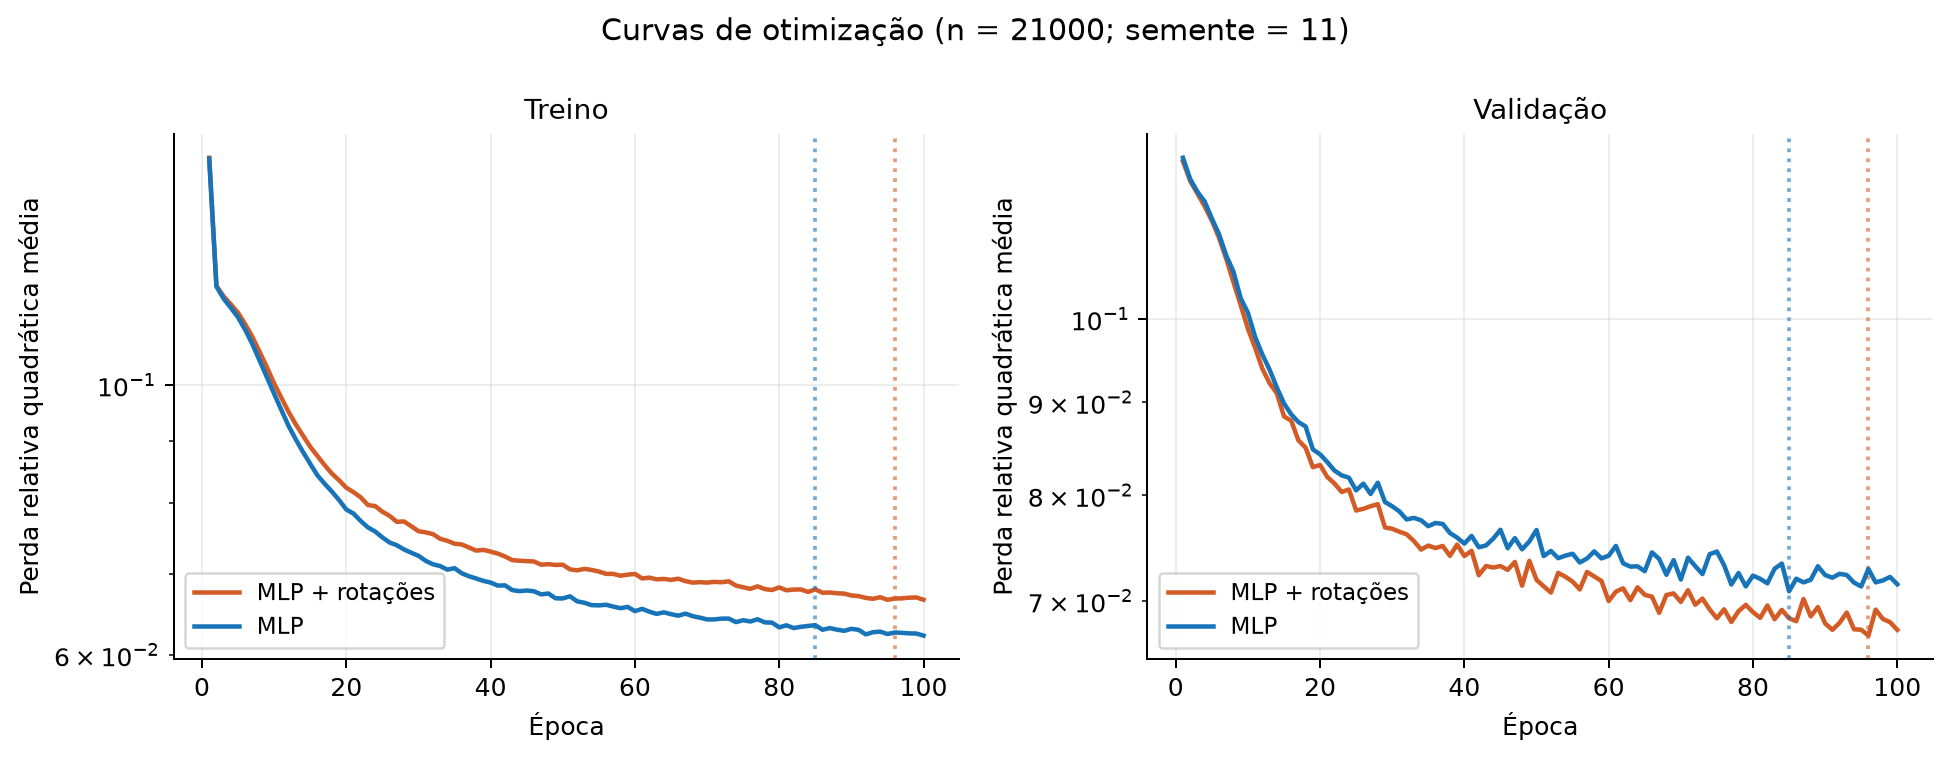

Figura 2 — Loss de treino e validação para a semente 11 com 21.000 fontes. Linhas pontilhadas indicam os checkpoints selecionados; as curvas usam a perda quadrática, não o erro não quadrático das tabelas.

A MLP comum tem menor loss de treino, mas a rede com rotações apresenta melhor
validação no final. O treino aumentado vê exemplos transformados e pode ser
mais difícil; menor loss de treino não implica melhor generalização. Muitas
execuções usam quase todas as 100 épocas, e isso não prova convergência completa.
Os históricos de todas as sementes foram salvos; a figura mostra uma delas.

### 7.3 Equivariância por rotações e mudanças de base

| Modelo | SO(7), ID | SO(7), OOD | GL⁺(7), ID | GL⁺(7), OOD |
| --- | ---: | ---: | ---: | ---: |
| Ridge | 0,01519 ± 0,00000 | 0,01323 ± 0,00000 | 0,21232 ± 0,00000 | 0,14588 ± 0,00000 |
| MLP | 0,23550 ± 0,00165 | 0,29848 ± 0,00570 | 0,26582 ± 0,00293 | 0,32436 ± 0,00273 |
| MLP com rotações | 0,22228 ± 0,00211 | 0,28175 ± 0,00777 | 0,25190 ± 0,00277 | 0,31183 ± 0,00442 |

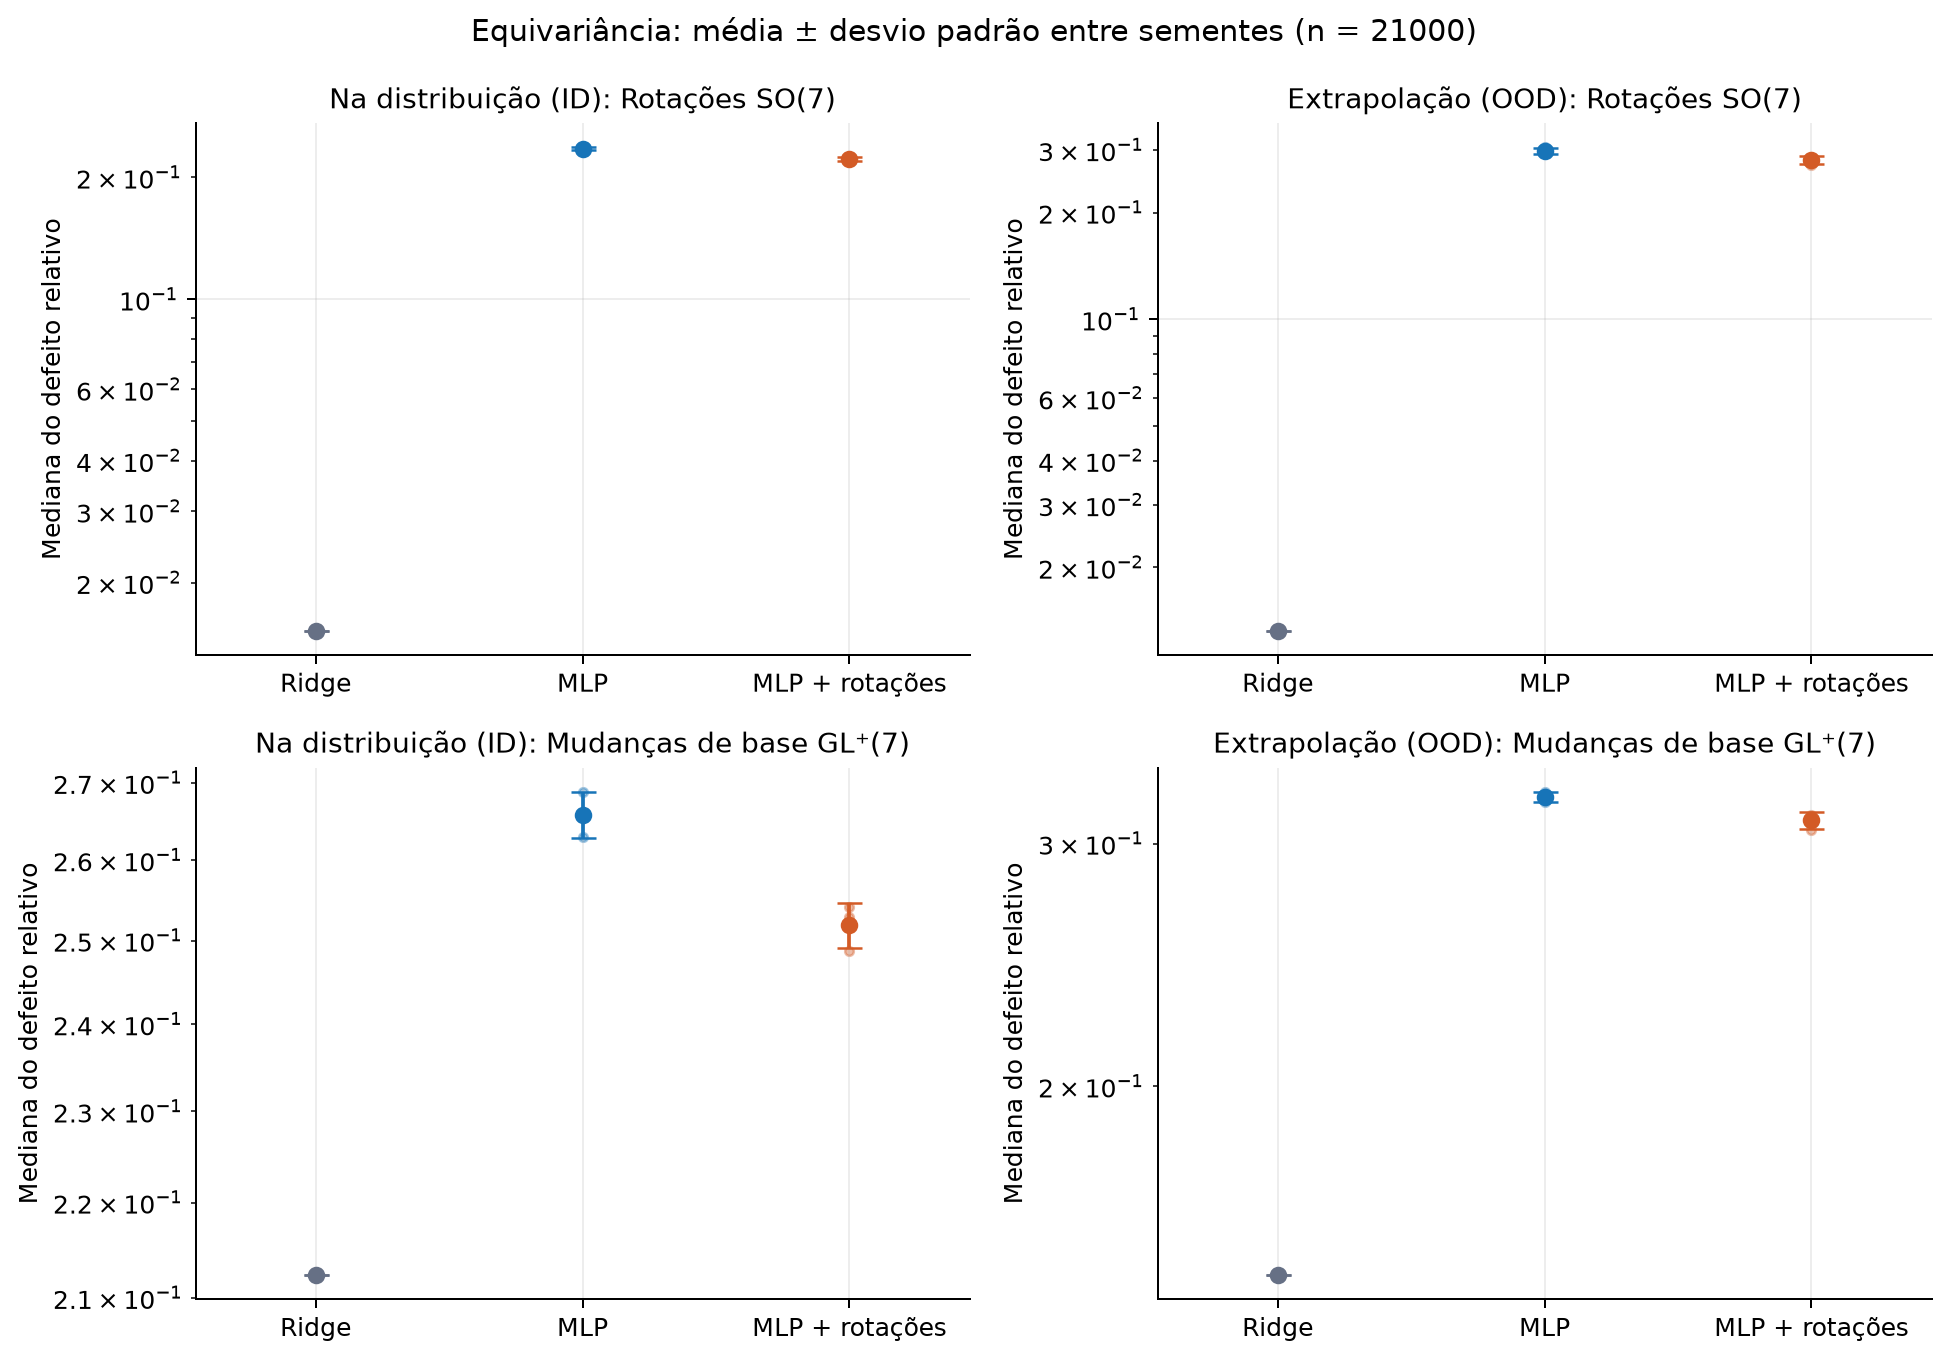

Figura 3 — Medianas dos defeitos geométricos no maior tamanho de treino. Barras: variabilidade entre sementes. A escala vertical difere entre painéis; compare valores, não alturas entre painéis.

A MLP com rotações reduz o defeito frente à MLP comum. Entretanto, o ridge
apresenta defeito SO(7) muito menor e precisão muito pior. Isso é compatível
com uma predição quase escalar constante. A inspeção do checkpoint ridge da
semente 11 encontrou média próxima de `1,08288 I` e variação relativa média
de apenas 1,12% em torno dessa matriz.

Esse número é uma observação do modelo treinado, não uma propriedade universal
da regressão ridge. Ele mostra concretamente por que precisamos avaliar
precisão e geometria em separado.

### 7.4 Homogeneidade e extrapolação de escala

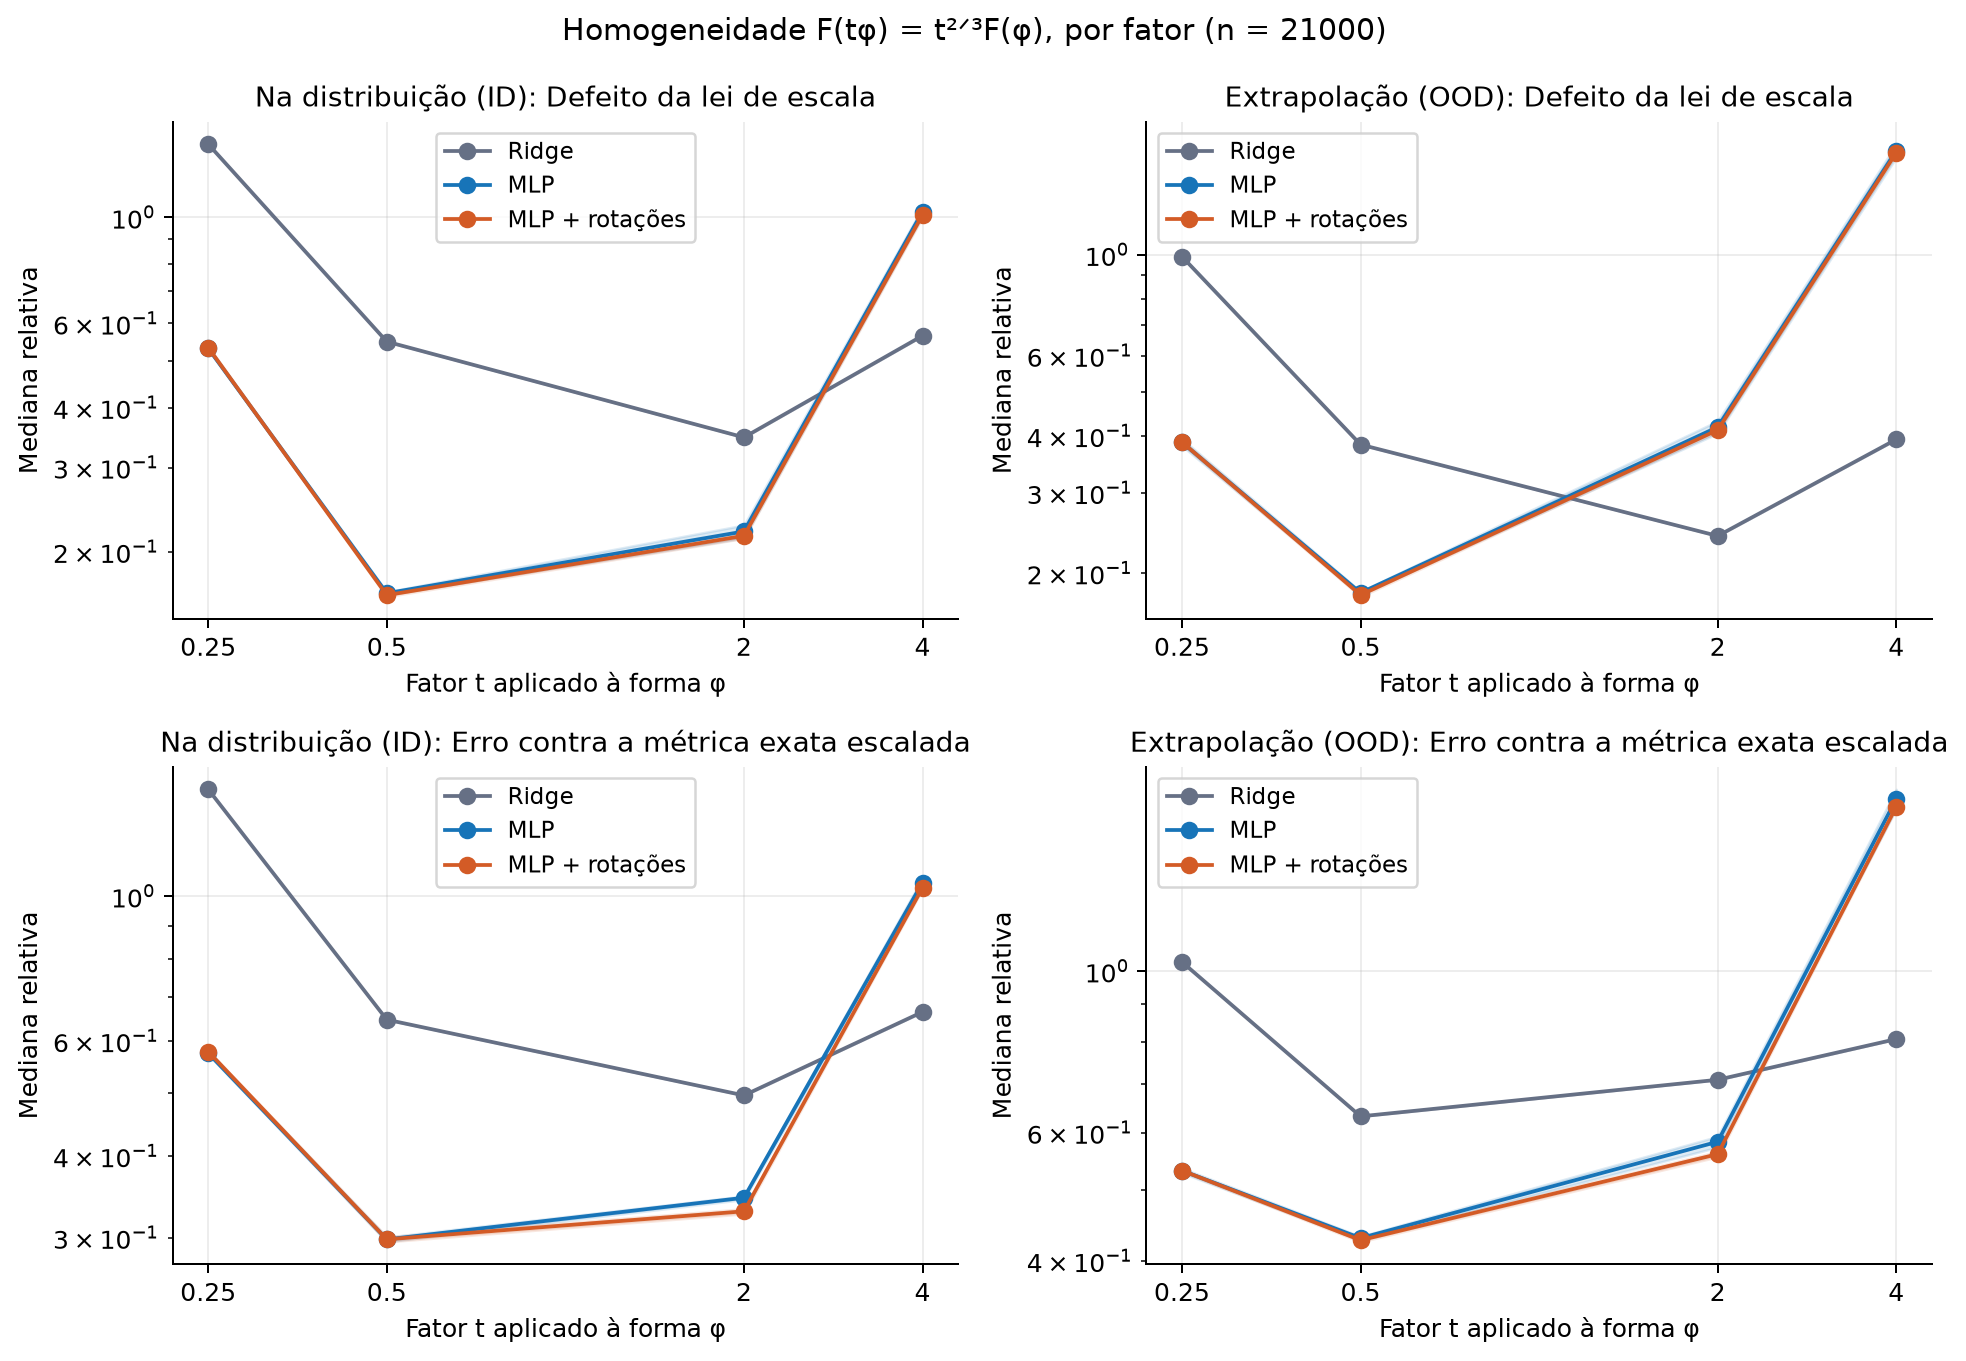

Figura 4 — Defeito da lei de escala (acima) e erro contra a métrica verdadeira escalada (abaixo). Cada ponto corresponde a um fator t aplicado à forma. Os títulos ID/OOD identificam o conjunto de origem; após escalar, a entrada pode sair dele.

O comportamento piora expressivamente em escalas distantes, sobretudo para
`t = 4`. Treinar com rotações não ensina automaticamente a homogeneidade de
grau 2/3. Um defeito de escala pequeno, por si só, também não bastaria:
o gráfico inferior mede se a resposta escalada é correta.

### 7.5 Recalcular a comparação com as medições incorporadas

A próxima célula contém 18 linhas de medições reais: três modelos, três
sementes e dois domínios, com 21.000 fontes. Os valores foram copiados
automaticamente do arquivo de resultados, sem arredondamento prévio.
Nenhum arquivo local é necessário para executar esta parte.

In [6]:
import csv
import io

CSV_MEDIDO = '''model,seed,domain,error_median,error_p95,eq_so7_median,eq_gl7_median,spd_failures,n
ridge,11,id,0.36583307776932317,0.48288362332820844,0.015188983983980177,0.21232073297564763,0,4500
ridge,11,ood,0.6229225453486682,0.7285984073820186,0.01322790158166989,0.14587746269446877,0,4500
mlp,11,id,0.258992945581891,0.34162785011298324,0.23619252228222953,0.26296741916412214,0,4500
mlp,11,ood,0.436121889716663,0.6407682357496227,0.2951401137424928,0.3269648362940647,0,4500
mlp_augmented,11,id,0.2506953585903209,0.33460195286214806,0.22432639249205827,0.24878373554852096,0,4500
mlp_augmented,11,ood,0.4279652185393895,0.624672014294341,0.28676942400921535,0.31434032882478935,0,4500
ridge,22,id,0.36583307776932317,0.48288362332820844,0.015188983983980178,0.21232073297564757,0,4500
ridge,22,ood,0.6229225453486682,0.7285984073820186,0.013227901581669876,0.14587746269446877,0,4500
mlp,22,id,0.2580958622401379,0.33779496876909837,0.23668936128567342,0.2688215759637099,0,4500
mlp,22,ood,0.43473786307590706,0.6490173028230014,0.3050562984184326,0.3246150211647152,0,4500
mlp_augmented,22,id,0.24944887865537657,0.33174379068238063,0.22239869682899466,0.25285963855774735,0,4500
mlp_augmented,22,ood,0.42779826034139046,0.6332704570162987,0.28567157672158483,0.31440982212427987,0,4500
ridge,33,id,0.36583307776932317,0.48288362332820844,0.015188983983980161,0.21232073297564757,0,4500
ridge,33,ood,0.6229225453486682,0.7285984073820186,0.013227901581669869,0.14587746269446877,0,4500
mlp,33,id,0.25727862686761926,0.3381136352435372,0.23362318605900695,0.2656710812558853,0,4500
mlp,33,ood,0.43611308088693623,0.6482875040884432,0.2952426605172628,0.32151500962556795,0,4500
mlp_augmented,33,id,0.2495631353503832,0.3310315509086398,0.22011297007188746,0.2540657964493658,0,4500
mlp_augmented,33,ood,0.4278842471827955,0.6282950887877687,0.2727951258307523,0.30672598141177543,0,4500
'''
medicoes = list(csv.DictReader(io.StringIO(CSV_MEDIDO)))
print(f'{len(medicoes)} medições reais incorporadas; nenhum treinamento executado.')

18 medições reais incorporadas; nenhum treinamento executado.


In [7]:
pares_ok = []
print("Seed  Domínio  Variação erro  Variação defeito SO(7)  Critério")
for seed in CONFIG["seeds"]:
    for dominio in ("id", "ood"):
        def medida(modelo, campo):
            linha = next(r for r in medicoes if r["model"] == modelo
                         and int(r["seed"]) == seed and r["domain"] == dominio)
            return float(linha[campo])
        razao_erro = medida("mlp_augmented", "error_median") / medida("mlp", "error_median")
        razao_defeito = medida("mlp_augmented", "eq_so7_median") / medida("mlp", "eq_so7_median")
        ok = razao_erro <= 1 + CONFIG["accuracy_tolerance_relative"] and razao_defeito < 1
        pares_ok.append(ok)
        print(f"{seed:4}  {dominio:7}  {razao_erro-1:+12.2%}  {razao_defeito-1:+22.2%}  {ok}")
print("Critério satisfeito em todos os pares:", all(pares_ok))

Seed  Domínio  Variação erro  Variação defeito SO(7)  Critério
  11  id             -3.20%                  -5.02%  True
  11  ood            -1.87%                  -2.84%  True
  22  id             -3.35%                  -6.04%  True
  22  ood            -1.60%                  -6.35%  True
  33  id             -3.00%                  -5.78%  True
  33  ood            -1.89%                  -7.60%  True
Critério satisfeito em todos os pares: True


O critério operacional foi satisfeito nesta configuração. Nos pares por semente,
o ganho de precisão não foi comprado com aumento do defeito de rotação.
A redução média relativa do defeito SO(7) ficou perto de 5,6% nos dois domínios;
a redução do erro mediano ficou perto de 3,2% em ID e 1,8% em OOD.

São comparações descritivas de três sementes sobre conjuntos finitos. Não houve
teste de significância ou prova para todas as formas positivas. O ridge, embora
geometricamente quase constante, continua sendo um comparador útil de precisão.

### 7.6 Verificação matemática e positividade

A validação inicial do gerador obteve erro relativo máximo de
**5.611e-16**, comparando a fórmula exterior
com AᵀA em amostras aleatórias ID e OOD. O erro na identidade foi
**0.0**. São valores compatíveis com arredondamento de ponto flutuante.

Foram registradas **0 falhas de positividade** nas predições dos conjuntos
ID/OOD somadas sobre as 54 avaliações (27 modelos × 2 domínios). Uma contagem
zero no ridge, se observada, não oferece garantia fora dessas amostras;
ele não impõe positividade por construção. A contagem refere-se aos conjuntos
base de teste, não a todas as entradas transformadas possíveis.

Os **24 testes automatizados** passaram. Eles cobrem fórmulas, composição,
escala, positividade, amostragem, splits, seleção por validação, transformação
dos rótulos, reprodutibilidade e gravação/leitura dos modelos. Os 27 checkpoints
reais também foram recarregados e comparados às predições salvas.

<a id="codigo"></a>
## 8. Como o repositório realiza essas ideias

Leia esta tabela como um caminho de dados. Cada módulo tem um papel; não é
necessário memorizar sua implementação para compreender o experimento.

| Arquivo | Entrada | Responsabilidade | Saída |
| --- | --- | --- | --- |
| `geometry.py` | Coeficientes de formas e matrizes | Pullback, amostragem SO(7)/GL⁺, fórmula exterior | Formas transformadas e métricas exatas |
| `data.py` | Quantidades, faixas, seed | Gerar pares, dividir fontes, validar e persistir | Arrays e NPZ com manifesto |
| `models.py` | Atributos de 35 dimensões | Padronizador, ridge, MLP e loss | Predições simétricas, com SPD na MLP |
| `training.py` | Dados de treino/validação e configuração | Otimizar, selecionar, salvar/carregar | Modelo ajustado e histórico |
| `evaluation.py` | Preditor e testes independentes | Medir erro, equivariância, escala, positividade | Métricas e predições individuais |
| `reporting.py` | Métricas e históricos | Agregar sementes e desenhar figuras | Relatório Markdown e PNGs |
| `experiment.py` | Configuração e pasta de destino | Coordenar geração, 27 ajustes e avaliação | Pasta completa de resultados |
| `__main__.py` | Comando `run`, `generate` ou `predict` | Interface de terminal | Chama o fluxo solicitado |
| `__init__.py` | Importação do pacote | Identificação e versão | Pacote `g2metric` |

Todos esses arquivos estão em `g2metric/`. As demais pastas têm funções distintas:

| Pasta/arquivo | Papel |
| --- | --- |
| `material-consulta/` | PDF original do planejamento |
| `configs/` | Parâmetros `smoke` e `full`; não são pesos aprendidos |
| `tests/` | Verificações matemáticas e de software |
| `docs/` | Decisões, resultados, declaração de IA e roteiro |
| `outputs/full/` | Experimento científico completo |
| `outputs/smoke/` | Verificação rápida do funcionamento |
| `outputs/example/` | Forma padrão e exemplo de inferência |
| `notebooks/` | Este documento, com resultados e imagens incorporados |
| `scripts/build_notebook.py` | Monta este notebook a partir dos resultados registrados |
| `README.md` | Porta de entrada e comandos de uso |
| `pyproject.toml`, `requirements*.txt` | Pacote e dependências |
| `.gitignore` | O que o Git deve ignorar; não apaga arquivos |
| `.venv/`, `.tools/` | Ambiente e ferramentas locais, não conteúdo científico |

**Exemplo de nome:** `mlp_augmented_n21000_seed11.pt` é a rede com rotações,
ajustada com 21.000 fontes e seed 11. Seu arquivo inclui pesos, padronização e
identificação das fontes. Em `histories/`, o mesmo nome com `.json` contém as
losses e a época escolhida. Em `predictions/`, os sufixos `_id` e `_ood` distinguem
os testes. O notebook incorpora as medições e as figuras, mas não carrega todos
os pesos ou 34.500 pares; eles não são necessários para lê-lo ou rodar seus exemplos.

### Usar o projeto depois de compreendê-lo

Os comandos abaixo são **referências de uso**, não células executadas por este notebook.
No PowerShell, dentro de AI-Project:

```powershell
# Conferir as verificações
.\.venv\Scripts\python.exe -m pytest -q

# Novo ensaio curto: escolha uma pasta que ainda não exista
.\.venv\Scripts\python.exe -m g2metric run --config configs/smoke.json --output outputs/meu-estudo

# Inferência com um checkpoint real já treinado
.\.venv\Scripts\python.exe -m g2metric predict --checkpoint outputs/full/checkpoints/mlp_augmented_n21000_seed11.pt --input outputs/example/phi0.npy --output outputs/example/minha-metrica.npy
```

O perfil completo usa `configs/full.json` e pode ser executado em outra pasta
de saída. Os comandos recusam sobrescrever resultados existentes. Os arquivos
`dataset.npz`, `checkpoints/` e `predictions/` são ignorados pelo Git e podem não
estar presentes em uma cópia obtida apenas por clone; nesse caso, execute o
experimento para regenerá-los. Isso não afeta a leitura deste notebook.

<a id="conclusoes"></a>
## 9. Conclusões e próximos passos possíveis

1. A fórmula geométrica e o gerador foram validados por caminhos independentes.
2. A MLP aproxima o mapa melhor que o comparador linear nesse protocolo.
3. Rotacionar os dados melhora modestamente a precisão e o defeito SO(7) nas três sementes.
4. A extrapolação e a homogeneidade permanecem limitações importantes.
5. Baixo defeito geométrico não substitui precisão: o ridge quase constante ilustra isso.

A implementação combina Python/NumPy/PyTorch, ridge, MLP, Adam, protocolo de
avaliação e aprendizagem com simetrias. A geometria G₂ e a saída por fator
triangular seguem o planejamento do projeto.

Possíveis estudos posteriores incluem maior orçamento de treinamento, outras
larguras de rede e formas de incorporar a lei de escala. Eles seriam **novos
experimentos**, com seleção pela validação e teste final reservado ou renovado;
não devem ser apresentados como se já tivessem sido executados. Uma arquitetura
exatamente GL⁺(7)-equivariante foi expressamente deixada fora do escopo original.

Para verificar sua compreensão, tente responder: por que não gerar A apenas
ortogonal? Por que o rótulo muda na augmentação? Por que padronizar não é
normalizar cada amostra? Por que o ridge pode vencer em equivariância e perder
em precisão? As seções 3, 4 e 7 contêm as respostas.

<a id="referencias"></a>
## 10. Reprodutibilidade, glossário e referências

| Termo | Significado neste projeto |
| --- | --- |
| Atributo / feature | Um dos 35 coeficientes usados como entrada |
| Rótulo / target | Métrica exata que supervisiona o modelo |
| Parâmetro do modelo | Peso/intercepto ajustado pelo algoritmo |
| Hiperparâmetro | Escolha como largura, learning rate, alpha ou orçamento |
| Batch | Grupo de exemplos usado em uma atualização |
| Época | Uma passagem pelas fontes de treino, com novas rotações no braço aumentado |
| Seed / semente | Inicialização de uma sequência pseudoaleatória reproduzível |
| Checkpoint | Estado salvo do modelo, aqui selecionado pela validação |
| SPD | Simétrica positiva definida |
| Generalização | Desempenho em exemplos que não ajustaram os pesos |
| Extrapolação | Desempenho fora da faixa de geração do treino |
| Equivariância | Compatibilidade da previsão com ações nos espaços de entrada e saída |

As versões, configurações, identificadores das fontes e hashes foram registrados.
Reproduzir sementes não garante resultados idênticos entre todo hardware e
versão de biblioteca. Nesta execução foi usado determinismo do PyTorch, CPU e
geradores separados para dados, divisão, minibatches e rotações.

O desenvolvimento contou com assistência de IA para leitura, programação,
revisão e documentação. A verificação inclui testes numéricos por rotas diferentes,
mas não substitui demonstrações ou revisão científica humana. O notebook não é
um artigo revisado nem uma descoberta matemática.

In [8]:
PROVENIENCIA = json.loads(r'''{
  "execucao": "outputs/full",
  "versoes_do_experimento": {
    "python": "3.12.14 (main, Sep 29 2026, 15:00:58) [MSC v.1944 64 bit (AMD64)]",
    "numpy": "2.5.3",
    "torch": "2.14.1+cpu"
  },
  "plataforma": "Windows-11-10.0.26200-SP0",
  "dataset_sha256": "b38aadabba8cb93a8440b75c1ff0b4363a919a23b0ce2b2730d0fa0b2ec64915",
  "metrics_sha256": "113ae8453f84523e4b6cae4d866ee44409bb43948368add2a21ca6b3a6c2604f",
  "verificacao_exterior": 5.611106209399018e-16,
  "fontes_do_experimento_sha256": {
    "g2metric/__init__.py": "4b817c5f660fcf23ab3396439d005e85ceea04410a5f7ea9f3f6fdfd04b4420a",
    "g2metric/__main__.py": "739bc0c43d1cbafc0bed5b0d21e14c178a0baacfb8b9933648786518f4765599",
    "g2metric/data.py": "13bc3540b0e2e8534bd6b04909533cf277fd8b830631e73550a31f41ccae75f5",
    "g2metric/evaluation.py": "a6632c6ba4e8d877215a9921f4b7cff65e707b2aaca62424c5e6be582fb2aacd",
    "g2metric/experiment.py": "6b57c720b1d7c00b03c3e7c4a3b9d1711fc1492a2a854385aa54ddc70c594f5b",
    "g2metric/geometry.py": "fd1e6dbacbcb600ad38dfb4dcb3f2b2f5bb65c3f797e3b9f849a03d4b5022caf",
    "g2metric/models.py": "d8c18a9f3eeafd90708797f8e69bd5e7d236d890de7a0eea4251a2ada565a31c",
    "g2metric/reporting.py": "d1f61f583fe15794d8bc2a34d4b7725a1faa4bddba0e7e87ce33dd6d83fa1c98",
    "g2metric/training.py": "34ec3bb5154a75edf330d23ca30ad3413de797c52a431760d0077130a805267f"
  }
}''')
print(json.dumps({k: v for k, v in PROVENIENCIA.items() if k != 'fontes_do_experimento_sha256'}, ensure_ascii=False, indent=2))

{
  "execucao": "outputs/full",
  "versoes_do_experimento": {
    "python": "3.12.14 (main, Sep 29 2026, 15:00:58) [MSC v.1944 64 bit (AMD64)]",
    "numpy": "2.5.3",
    "torch": "2.14.1+cpu"
  },
  "plataforma": "Windows-11-10.0.26200-SP0",
  "dataset_sha256": "b38aadabba8cb93a8440b75c1ff0b4363a919a23b0ce2b2730d0fa0b2ec64915",
  "metrics_sha256": "113ae8453f84523e4b6cae4d866ee44409bb43948368add2a21ca6b3a6c2604f",
  "verificacao_exterior": 5.611106209399018e-16
}


### Fontes usadas

- **Planejamento do projeto**, Eduardo Toffolo, *Learning the Metric Induced by a G₂-Structure: Generalisation and Equivariance*, 3 páginas. No repositório: `material-consulta/Planajamento de projeto.pdf` (grafia original preservada).
- S. Karigiannis, [Introduction to G₂ geometry](https://arxiv.org/abs/1909.09717).
- S. Grigorian, [Deformations of G₂-structures with torsion](https://arxiv.org/abs/1108.2465), seção 2, para as convenções e a fórmula da métrica.
- S. Chen, E. Dobriban e J. H. Lee, [A Group-Theoretic Framework for Data Augmentation](https://jmlr.org/papers/v21/20-163.html).
- Documentação oficial de [reprodutibilidade do PyTorch](https://docs.pytorch.org/docs/stable/notes/randomness.html).

As figuras e tabelas foram incorporadas diretamente da execução `full`, sem
retreinar ou modificar os modelos ao preparar este documento. Os metadados
personalizados do notebook também guardam os 54 registros de métricas completos,
a configuração e a proveniência para auditoria.